In [1]:
%run data_loader.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

from sklearn.ensemble import HistGradientBoostingClassifier

Config loaded
preprocess_binary() defined
load_all_datasets() defined
Project root:          /Users/yogeshpatel/Desktop/Tilak/IDS_project
CICIDS2018 folder exists: False
load_cicids2018() defined


In [2]:
datasets = load_all_datasets()

print(f"Loaded: {list(datasets.keys())}")

Loading 8 dataset(s): ['monday', 'bruteforce', 'dos', 'web_attacks', 'infiltration', 'botnet', 'portscan', 'ddos']

  [monday]  Monday-WorkingHours.pcap_ISCX.csv
           raw (529918, 79)  ->  clean (502650, 81)  (attack rate 0.0%)
  [bruteforce]  Tuesday-WorkingHours.pcap_ISCX.csv
           raw (445909, 79)  ->  clean (421626, 81)  (attack rate 2.2%)
  [dos]  Wednesday-workingHours.pcap_ISCX.csv
           raw (692703, 79)  ->  clean (610492, 81)  (attack rate 31.7%)
  [web_attacks]  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
           raw (170366, 79)  ->  clean (164179, 81)  (attack rate 1.3%)
  [infiltration]  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
           raw (288602, 79)  ->  clean (252790, 81)  (attack rate 0.0%)
  [botnet]  Friday-WorkingHours-Morning.pcap_ISCX.csv
           raw (191033, 79)  ->  clean (184044, 81)  (attack rate 1.1%)
  [portscan]  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
           raw (286467, 79)  ->  clea

In [3]:
combined = pd.concat(datasets.values(), ignore_index=True)

print("Combined shape:", combined.shape)

print("\nBinary label distribution:")
print(combined["Label_Binary"].value_counts())

Combined shape: (2572640, 81)

Binary label distribution:
Label_Binary
0    2146899
1     425741
Name: count, dtype: int64


In [4]:
X = combined.drop(columns=["Label", "Label_Binary", "Source_File"])
y = combined["Label_Binary"]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median(numeric_only=True))

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (2058112, 78)
X_test : (514528, 78)


In [6]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [7]:
hgb_model = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)

hgb_model.fit(X_train, y_train)

HistGradientBoostingClassifier(max_depth=8, random_state=42)

In [8]:
y_pred_hgb = hgb_model.predict(X_test)
y_scores_hgb = hgb_model.predict_proba(X_test)[:, 1]

In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("HistGradientBoosting Results")

print("Accuracy :", round(accuracy_score(y_test, y_pred_hgb), 4))
print("Precision:", round(precision_score(y_test, y_pred_hgb), 4))
print("Recall   :", round(recall_score(y_test, y_pred_hgb), 4))
print("F1 Score :", round(f1_score(y_test, y_pred_hgb), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_scores_hgb), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_hgb))

HistGradientBoosting Results
Accuracy : 0.9989
Precision: 0.9964
Recall   : 0.997
F1 Score : 0.9967
ROC-AUC  : 1.0

Confusion Matrix:
[[429076    304]
 [   252  84896]]


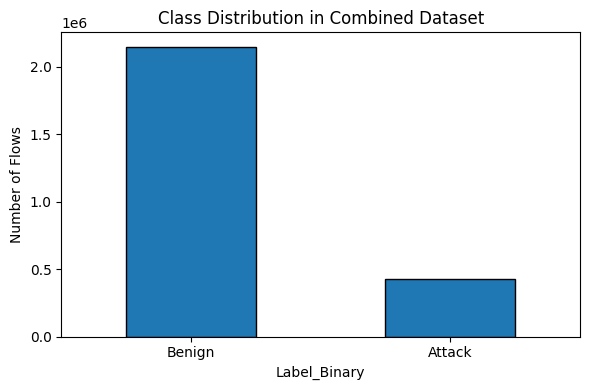

In [10]:
# Class Distribution in Combined Dataset
plt.figure(figsize=(6, 4))

combined["Label_Binary"].value_counts().sort_index().plot(
    kind="bar",
    edgecolor="black"
)

plt.xticks([0, 1], ["Benign", "Attack"], rotation=0)
plt.ylabel("Number of Flows")
plt.title("Class Distribution in Combined Dataset")
plt.tight_layout()
plt.show()

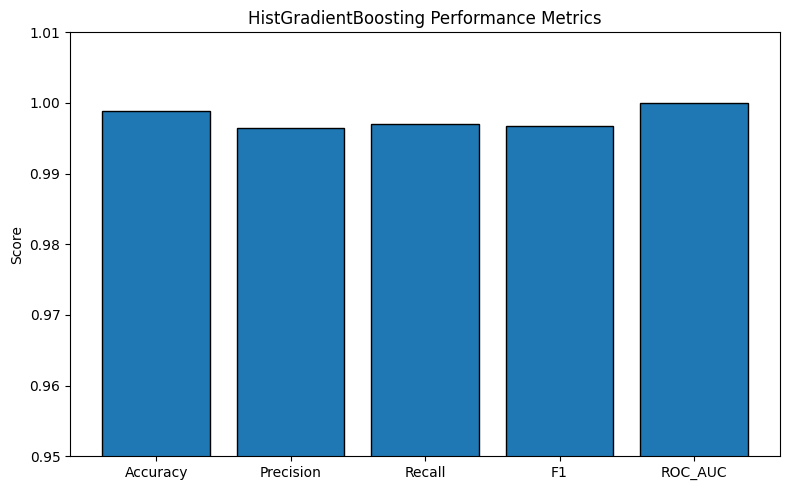

In [11]:
# Performance Metrics for HistGradientBoosting
results_df = pd.DataFrame([
    {
        "Model": "HistGradientBoosting",
        "Accuracy": accuracy_score(y_test, y_pred_hgb),
        "Precision": precision_score(y_test, y_pred_hgb),
        "Recall": recall_score(y_test, y_pred_hgb),
        "F1": f1_score(y_test, y_pred_hgb),
        "ROC_AUC": roc_auc_score(y_test, y_scores_hgb)
    }
]).round(4)

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]

plt.figure(figsize=(8, 5))
plt.bar(
    metrics,
    [results_df.iloc[0][m] for m in metrics],
    edgecolor="black"
)

plt.ylim(0.95, 1.01)
plt.ylabel("Score")
plt.title("HistGradientBoosting Performance Metrics")
plt.tight_layout()
plt.show()

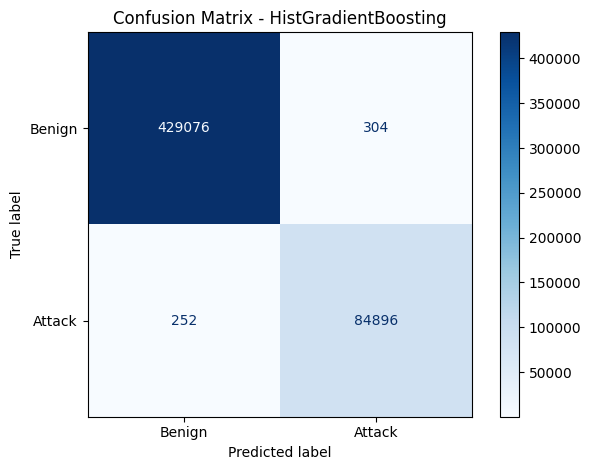

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_hgb,
    display_labels=["Benign", "Attack"],
    cmap="Blues"
)

plt.title("Confusion Matrix - HistGradientBoosting")
plt.tight_layout()
plt.show()

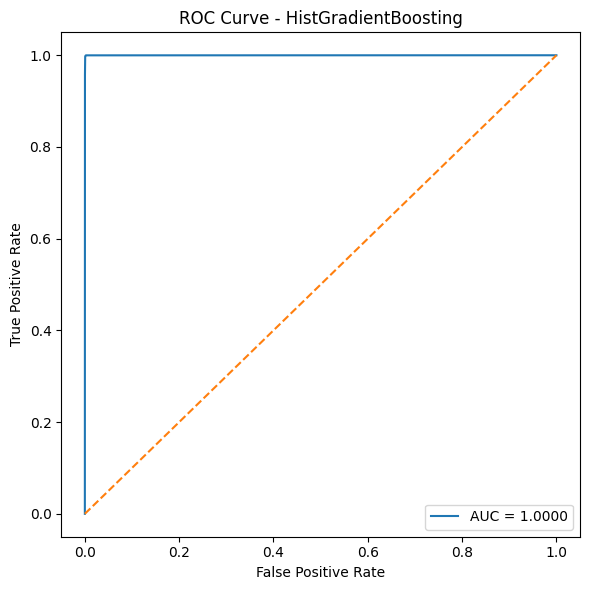

In [13]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_scores_hgb)

plt.figure(figsize=(6, 6))
plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test, y_scores_hgb):.4f}"
)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - HistGradientBoosting")
plt.legend()
plt.tight_layout()
plt.show()

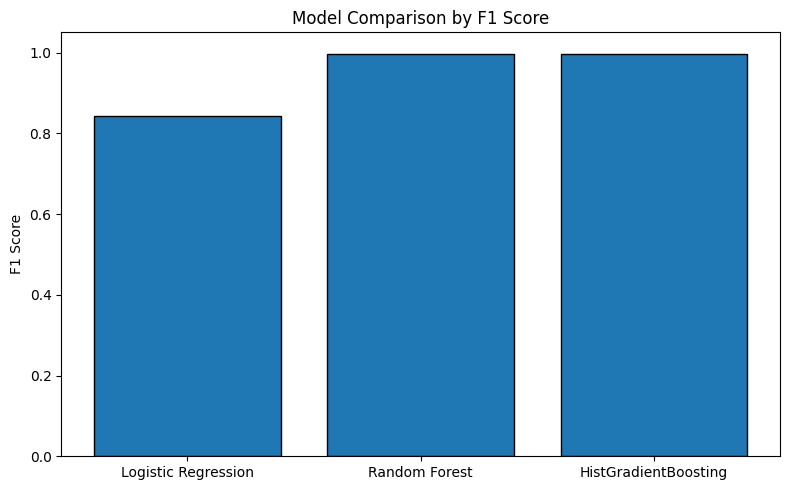

In [14]:
comparison_df = pd.DataFrame([
    ["Logistic Regression", 0.8428],
    ["Random Forest", 0.9958],
    ["HistGradientBoosting", 0.9967]
], columns=["Model", "F1"])

plt.figure(figsize=(8, 5))
plt.bar(
    comparison_df["Model"],
    comparison_df["F1"],
    edgecolor="black"
)

plt.ylim(0, 1.05)
plt.ylabel("F1 Score")
plt.title("Model Comparison by F1 Score")
plt.tight_layout()
plt.show()